# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [112]:
ПІБ = 'Федів Андрій'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 13     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [113]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Федів Андрій, ШІ-34, варіант 13
ваш потік:                   P>1
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = 'lab1.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [115]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ)
print(df.head())
print(df.dtypes)

   Unnamed: 0        ftp://ftp.swpc.noaa.gov/pub/lists/particle/ Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12  \
0         NaN                                                NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
1         NaN                :Data_list: 20170901_Gs_part_5m.txt        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
2         NaN                     :Created: 2017 Sep 02 0011 UTC        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
3         NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN         NaN         NaN   
4         NaN  # Please send comments an

**Відповідь 1.1:** тому, що таблиця містить мета дані, та і формат у неї поганий, зліплено 3 таблиці підряд

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [116]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ, header=None)
print(df.head(30))
print(df.shape)

    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and suggestions

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [117]:
# ВАШ КОД
df.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** логічно припустити, що ж 3 таблиці, з колонками 1-14 16-19 та 24-31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [118]:
# ВАШ КОД
filled = df.notna().sum()
cols = filled[filled > 0].index
bounds = [[cols[0], cols[0]]]
for c in cols[1:]:
    if c == bounds[-1][1] + 1:
        bounds[-1][1] = c
    else:
        bounds.append([c, c])

for a, b in bounds:
    table = df.iloc[:, a:b + 1]
    hat = table.notna().all(axis=1).idxmax()
    print('===============', a, b, hat)
    for i, v in table.iloc[:hat+1].stack().items():
        print(i, '|', v)


=============== 1 14 25
(0, 1) | ftp://ftp.swpc.noaa.gov/pub/lists/particle/
(2, 1) | :Data_list: 20170901_Gs_part_5m.txt
(3, 1) | :Created: 2017 Sep 02 0011 UTC
(4, 1) | # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
(5, 1) | # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
(6, 1) | # 
(7, 1) | # Label: P > 1 = Particles at >1 Mev
(8, 1) | # Label: P > 5 = Particles at >5 Mev
(9, 1) | # Label: P >10 = Particles at >10 Mev
(10, 1) | # Label: P >30 = Particles at >30 Mev
(11, 1) | # Label: P >50 = Particles at >50 Mev
(12, 1) | # Label: P>100 = Particles at >100 Mev
(13, 1) | # Label: E>0.8 = Electrons at >0.8 Mev
(14, 1) | # Label: E>2.0 = Electrons at >2.0 Mev
(15, 1) | # Label: E>4.0 = Electrons at >4.0 Mev
(16, 1) | # Units: Particles = Protons/cm2-s-sr
(17, 1) | # Units: Electrons = Electrons/cm2-s-sr
(18, 1) | # Source: GOES-15
(19, 1) | # Location: W135
(20, 1) | # Missing data: -1.00e+05
(22, 1) | 5-minute  GOES-15 Solar Particl

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання | | missing data |
|---|---|---|---|---|
| A | NOAA SWPC, GOES-15 (W135), 5-minute | Particles = Protons/cm2-s-sr | Electrons = Electrons/cm2-s-sr | -1.00e+05 |
| B | NOAA SWPC, Daily Solar Data (2017Q3_DSD.txt), daily | Radio Flux 10.7, s.f.u. | | not stated |
| C | SOHO CELIAS Proton Monitor, hour averages | Proton speed [km/sec] | Proton density [protons per cubic centimeter] | not stated (насправді -1) |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [119]:
# ВАШ КОД
num = lambda d: d.apply(pd.to_numeric, errors='coerce').dropna(how='all')

A = num(df.iloc[26:, 1:15])
A.columns = ['year', 'month', 'day', 'hhmm', 'mjd', 'sec_of_day',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

B = num(df.iloc[27:, 16:20])
B.columns = ['year', 'month', 'day', 'Radio Flux 10.7']

# columns 24 and 25 are row counters, not data
C = num(df.iloc[27:, 26:32])
C.columns = ['year', 'month', 'day', 'hour', 'speed', 'density']

print(A.shape, B.shape, C.shape)


(7200, 14) (25, 4) (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [120]:
# ВАШ КОД
C['year'] = C['year'] + 2000        # in table C the year is stored as 17

A['ts'] = pd.to_datetime(A[['year', 'month', 'day']].assign(second=A['sec_of_day']))
B['ts'] = pd.to_datetime(B[['year', 'month', 'day']])
C['ts'] = pd.to_datetime(C[['year', 'month', 'day', 'hour']])

for name, t in [('A', A), ('B', B), ('C', C)]:
    print(f"{name} {t['ts'].min()} - {t['ts'].max()}")


A 2017-08-28 00:00:00 - 2017-09-21 23:55:00
B 2017-08-28 00:00:00 - 2017-09-21 00:00:00
C 2017-08-28 00:00:00 - 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [121]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [122]:
# ВАШ КОД
for name, t in [('A', A), ('B', B), ('C', C)]:
    print('==========', name, t.shape)
    print(t.dtypes)
    print('missing:')
    print(t.isna().sum())
    print('full duplicates:', t.duplicated().sum())
    print(t.describe())


========== A (7200, 15)
year                   int64
month                  int64
day                    int64
hhmm                   int64
mjd                    int64
sec_of_day             int64
P>1                  float64
P>5                  float64
P>10                 float64
P>30                 float64
P>50                 float64
P>100                float64
E>0.8                float64
E>2.0                float64
ts            datetime64[ns]
dtype: object
missing:
year          0
month         0
day           0
hhmm          0
mjd           0
sec_of_day    0
P>1           3
P>5           3
P>10          3
P>30          3
P>50          3
P>100         3
E>0.8         3
E>2.0         3
ts            0
dtype: int64
full duplicates: 0
         year        month          day         hhmm           mjd    sec_of_day           P>1          P>5         P>10         P>30         P>50       P>100          E>0.8          E>2.0  \
count  7200.0  7200.000000  7200.000000  7200.000000  

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [123]:
# ВАШ КОД
for col in ['speed', 'density']:
    print(f"{col} negative: {(C[col] < 0).sum()} | before: mean {C[col].mean():.2f}, min {C[col].min():.1f}")

C[['speed', 'density']] = C[['speed', 'density']].mask(C[['speed', 'density']] < 0)

for col in ['speed', 'density']:
    print(f"{col} | after: mean {C[col].mean():.2f}, min {C[col].min():.1f}")


speed negative: 8 | before: mean 506.55, min -1.0
density negative: 8 | before: mean 2.91, min -1.0
speed | after: mean 513.39, min 277.0
density | after: mean 2.96, min 0.1


**Відповідь 3.2:** це маркер пропуску (-1), а не вимірювання. По 8 штук у швидкості й густині.
Середня швидкість зросла з 506.55 до 513.39 км/с, густина з 2.91 до 2.96, мінімуми змінилися
з -1 на 277 км/с і 0.1. Тобто пропуски тягнули середнє вниз.


### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [124]:
# ВАШ КОД
print(A[['year', 'month', 'day', 'hhmm', 'mjd', 'sec_of_day']].describe())


         year        month          day         hhmm           mjd    sec_of_day
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   7200.000000
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000  43050.000000
std       0.0     0.366632     8.775483   692.481902      7.211603  24943.113498
min    2017.0     8.000000     1.000000     0.000000  57993.000000      0.000000
25%    2017.0     9.000000     7.000000   588.750000  57999.000000  21525.000000
50%    2017.0     9.000000    13.000000  1177.500000  58005.000000  43050.000000
75%    2017.0     9.000000    19.000000  1766.250000  58011.000000  64575.000000
max    2017.0     9.000000    31.000000  2355.000000  58017.000000  86100.000000


**Відповідь 3.3:** рік, місяць, день, hhmm, mjd, sec_of_day. Це мітки часу, а не вимірювання:
середній день 8.7 чи середні 43200 секунд доби нічого не означають, бо ці числа просто
рівномірно пробігають свій діапазон.


---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [125]:
# ВАШ КОД
values = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

Ah = A.set_index('ts')[values].resample('h').agg(['mean', 'max'])
Ah.columns = [f"{flux} {func}" for flux, func in Ah.columns]
Ah = Ah.reset_index()

print(Ah.shape)
Ah.head()


(600, 17)


,ts,P>1 mean,P>1 max,P>5 mean,P>5 max,P>10 mean,P>10 max,P>30 mean,P>30 max,P>50 mean,P>50 max,P>100 mean,P>100 max,E>0.8 mean,E>0.8 max,E>2.0 mean,E>2.0 max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

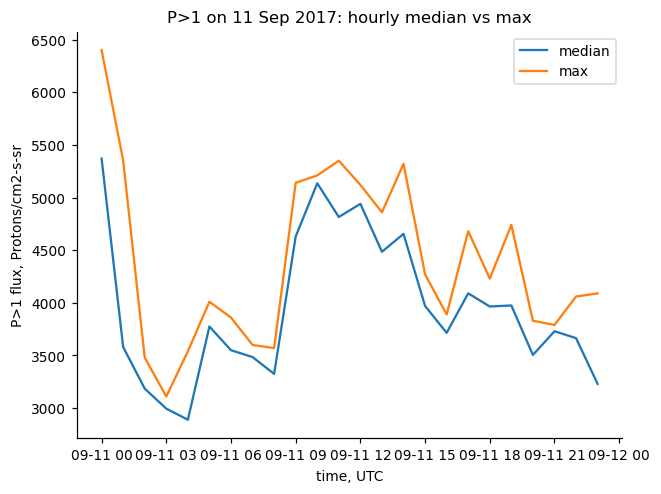

In [126]:
# ВАШ КОД
day = A[A['ts'].dt.date == pd.Timestamp('2017-09-11').date()]
hourly = day.set_index('ts')['P>1'].resample('h').agg(['median', 'max'])

plt.plot(hourly.index, hourly['median'], label='median')
plt.plot(hourly.index, hourly['max'], label='max')
plt.xlabel('time, UTC')
plt.ylabel('P>1 flux, Protons/cm2-s-sr')
plt.title('P>1 on 11 Sep 2017: hourly median vs max')
plt.legend()
plt.show()


**Відповідь 4.2:** максимум завжди вище медіани. Найбільша різниця о 01:00, і то лише в 1.5 раза. Різниця стає суттєвою в моменти спалаху: короткий викид підіймає максимум, а медіана його бачить тільки згодом.


### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [127]:
# ВАШ КОД
M_inner = Ah.merge(C[['ts', 'speed', 'density']], on='ts', how='inner')
M_outer = Ah.merge(C[['ts', 'speed', 'density']], on='ts', how='outer')
print('inner:', len(M_inner), 'outer:', len(M_outer))

M = M_inner
M['date'] = M['ts'].dt.normalize()
M = M.merge(B[['ts', 'Radio Flux 10.7']].rename(columns={'ts': 'date'}), on='date', how='left')
M = M.drop(columns='date')

print(M.shape)
M[M.isna().any(axis=1)]


inner: 600 outer: 601
(600, 20)


,ts,P>1 mean,P>1 max,P>5 mean,P>5 max,P>10 mean,P>10 max,P>30 mean,P>30 max,P>50 mean,P>50 max,P>100 mean,P>100 max,E>0.8 mean,E>0.8 max,E>2.0 mean,E>2.0 max,speed,density,Radio Flux 10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** inner дає 600 рядків, outer - 601. Зайвий рядок в outer це 22 вересня 00:00,
яке є тільки в C, а вимірювань потоків на нього немає. Обрано inner: рядок без половини даних
у роботі не потрібен. F10.7 доклеєно по добі (how='left'), одне значення розтягується на 24 години.
Пропуски лишилися тільки у швидкості й густині - 8 рядків


### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [128]:
# ВАШ КОД
M["група"] = pd.cut(M["P>10 max"], [-np.inf, 10, 1000, np.inf], labels=["quiet", "active", "very active"])
print(M["група"].value_counts().to_string())

група
quiet          411
active         171
very active     18


**Самоперевірка етапу 4.**

In [129]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

mean 689.2, median 59.3, max 15908.3


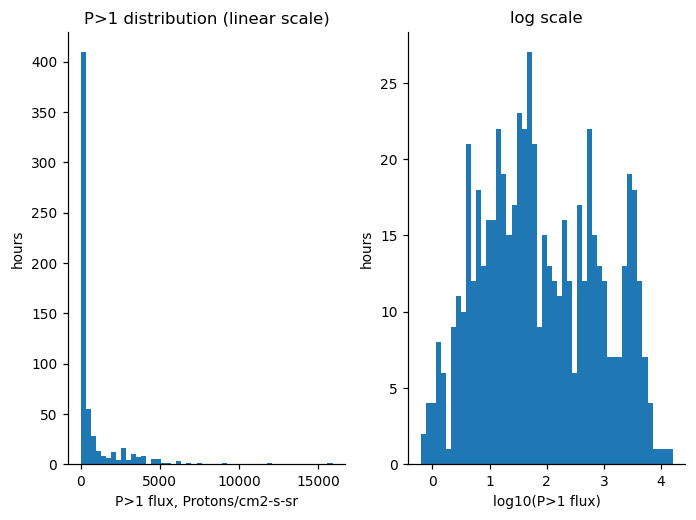

In [130]:
# ВАШ КОД
s = M['P>1 mean']
print(f"mean {s.mean():.1f}, median {s.median():.1f}, max {s.max():.1f}")

fig, ax = plt.subplots(1, 2)
ax[0].hist(s, bins=50)
ax[0].set_xlabel('P>1 flux, Protons/cm2-s-sr')
ax[0].set_ylabel('hours')
ax[0].set_title('P>1 distribution (linear scale)')

ax[1].hist(np.log10(s), bins=50)
ax[1].set_xlabel('log10(P>1 flux)')
ax[1].set_ylabel('hours')
ax[1].set_title('log scale')
fig.tight_layout()
plt.show()


**Висновок:** медіана 59.3, а середнє 689.2 - у 11 разів більше, бо кілька годин з
максимумом 15908 тягнуть середнє вгору. У звичайній шкалі видно один стовпчик інші значення відносно нього практично 0,
у логарифмі - що значення розтягнуті на всю шкалу


### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

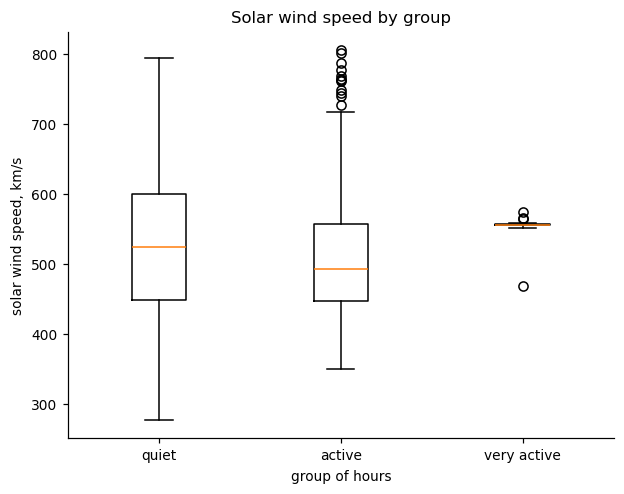

група
quiet          524.0
active         492.0
very active    556.0


In [131]:
# ВАШ КОД
groups = ['quiet', 'active', 'very active']
data = [M.loc[M['група'] == g, 'speed'].dropna() for g in groups]

plt.boxplot(data, tick_labels=groups)
plt.xlabel('group of hours')
plt.ylabel('solar wind speed, km/s')
plt.title('Solar wind speed by group')
plt.show()

print(M.groupby('група', observed=True)['speed'].median().to_string())


**Висновок:** медіани майже однакові - 524, 492 і 556 км/с, коробки сильно перекриваються.
Потоки протонів і швидкість вітру тут не пов'язані. Але група very active має ситуацію де швидкість практично одинакова, що може свідчити про те що це відбувалося на одному проміжку часу


### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

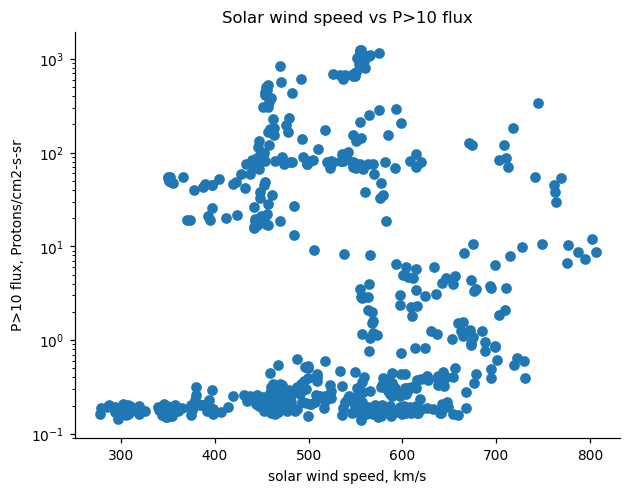

correlation: 0.071


In [132]:
# ВАШ КОД
plt.scatter(M['speed'], M['P>10 mean'])
plt.yscale('log')
plt.xlabel('solar wind speed, km/s')
plt.ylabel('P>10 flux, Protons/cm2-s-sr')
plt.title('Solar wind speed vs P>10 flux')
plt.show()

print(f"correlation: {M['speed'].corr(M['P>10 mean']):.3f}")


**Висновок:** кореляція 0.07, на діаграмі просто хмара без напрямку. Зв'язку між швидкістю
вітру і потоком P>10 у цих даних немає.


### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

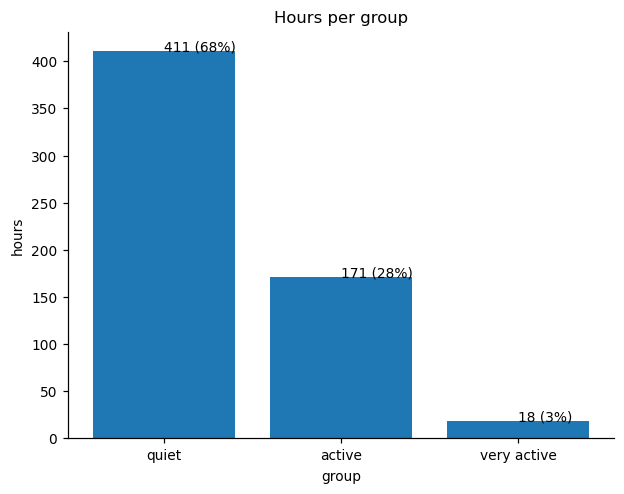

In [133]:
# ВАШ КОД
counts = M['група'].value_counts()[['quiet', 'active', 'very active']]
total = counts.sum()

plt.bar(counts.index, counts.values)
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v} ({100 * v / total:.0f}%)")
plt.xlabel('group')
plt.ylabel('hours')
plt.title('Hours per group')
plt.show()


**Висновок:** 411 годин (68%) тихі, 171 (28%) активні і лише 18 (3-4%) дуже активні.
Більшість часу нічого не відбувається. Спокій...


### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

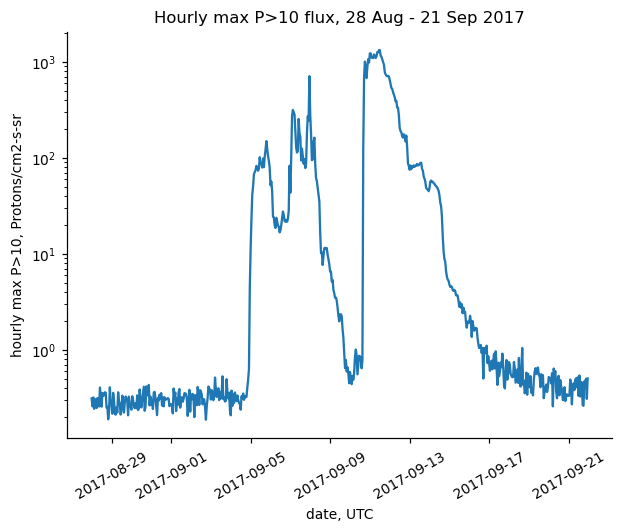

In [134]:
# ВАШ КОД
plt.plot(M['ts'], M['P>10 max'])
plt.yscale('log')
plt.xlabel('date, UTC')
plt.ylabel('hourly max P>10, Protons/cm2-s-sr')
plt.title('Hourly max P>10 flux, 28 Aug - 21 Sep 2017')
plt.xticks(rotation=30)
plt.show()


**Висновок:** до 5 вересня рівний фон близько 0.3, далі два сплески - 7-8 і 10-11 вересня.
Пік 11 вересня. Без логарифмічної шкали весь фон зливається майже в пряму лінію біля нуля.


---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

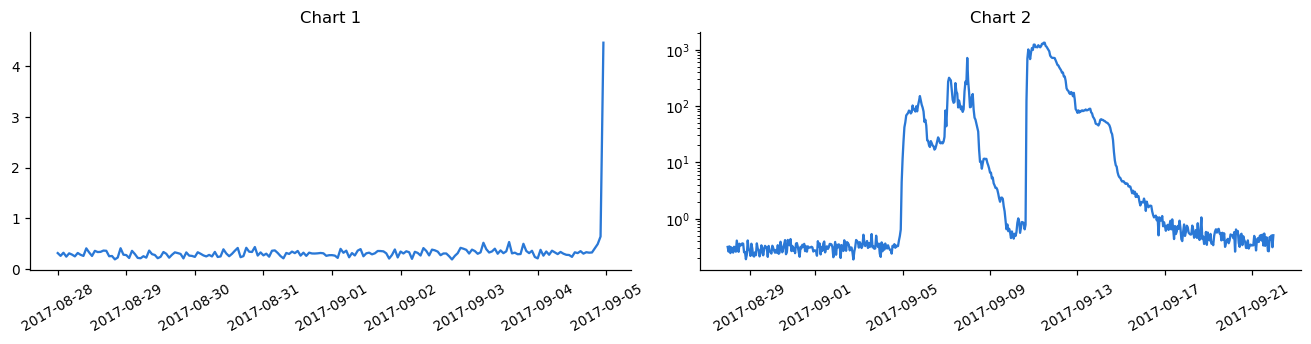

In [135]:
СТОВПЕЦЬ = 'P>10 max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Chart 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Chart 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()


### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: кінець серпня - початок вересня спокійний, потік тримається
   в межах одиниць і нічого не відбувається.
2. Висновок з другого графіка: 7-8 і 10-11 вересня були спалахи, потік піднявся на 3.5 порядки
   над фоном.
3. Дві відмінності між ними: перший показує лише 28.08-05.09 і обривається саме перед подією,
   другий - увесь період; перший у лінійній шкалі, другий у логарифмічній.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

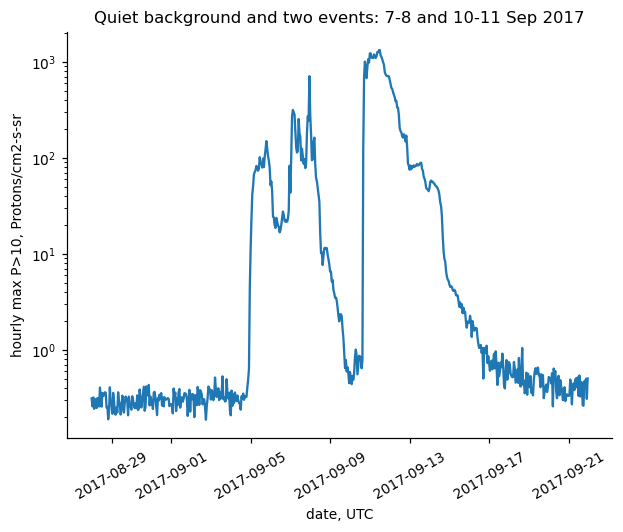

In [136]:
# ВАШ КОД
plt.plot(M['ts'], M['P>10 max'])
plt.yscale('log')
plt.xlabel('date, UTC')
plt.ylabel('hourly max P>10, Protons/cm2-s-sr')
plt.title('Quiet background and two events: 7-8 and 10-11 Sep 2017')
plt.xticks(rotation=30)
plt.show()


)*;?К№"?*:?№"?:!"№:"()(*?:?%;№";:%:?

**Відповідь 6.2:** весь період, щоб не можна було обрізати незручний шматок, і логарифмічна
шкала, бо значення розтягнуті на 3.5 порядки. 


---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** середнє P>1 (689.2) у 11 разів більше за медіану (59.3) - графік 1.
Кілька годин спалаху перетягують середнє, тому середнє тут не описує типову годину.

**Спостереження 2:** 68.5% годин тихі й лише 3% дуже активні (графік 4), причому всі
18 дуже активних годин припадають на 10-11 вересня - графік 5.

**Спостереження 3:** кореляція швидкості вітру з потоком P>10 всього 0.07, а медіани
швидкості по групах майже однакові (524 / 492 / 556 км/с) - графіки 2 і 3. Тобто потік
протонів не пояснюється швидкістю вітру.


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [137]:
# ВАШ КОД
peak = M["P>1 mean"].idxmax()
print(f"peak: {M.loc[peak, 'ts']} = {M.loc[peak, 'P>1 mean']:.1f}")

window = M.loc[peak - 12 : peak + 11, "P>1 mean"]
share = window.sum() / M["P>1 mean"].sum()
print(f"hours in window: {len(window)}")
print(f"share of total: {100 * share:.1f}%")

peak: 2017-09-07 00:00:00 = 15908.3
hours in window: 24
share of total: 18.3%


**Відповідь 7.2:** пік P>1 припав на 7 вересня 00:00 (15908). 24 години навколо нього дали
18.3% усієї суми потоку за 25 діб. Тобто 4% часу дають майже пʼяту частину всього потоку -
події короткі, але важать більше за весь спокійний фон разом.


---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [146]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = (
    'як b+1, інакше губиться останній стовпець. Перевірив, що в таблиці C стовпці 24-25 це '
    'лічильники, а не дані, і що рік там записаний як 17'
    'Перерахував середню швидкість до і після заміни -1 на NaN: 506.55 та 513.39. Звірив '
    'кореляцію 0.07 з виглядом діаграми розсіювання і суму по вікну 24 годин - 18.3%.'
)

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True


In [147]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Федів Андрій
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
як b+1, інакше губиться останній стовпець. Перевірив, що в таблиці C стовпці 24-25 це лічильники, а не дані, і що рік там записаний як 17Перерахував середню швидкість до і після заміни -1 на NaN: 506.55 та 513.39. Звірив кореляцію 0.07 з виглядом діаграми розсіювання і суму по вікну 24 годин - 18.3%.
Автор підтверджує, що може

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [142]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [141]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
